## Full clustering pipeline (feature selection, scaling, experiments, evaluation)

The cells below load the processed `clients_features.csv`, select numeric features, scale them, run KMeans/Agglomerative/DBSCAN, evaluate with silhouette and Calinski-Harabasz scores, and save labels + models and visualizations into `outputs/` and `data/processed`.

In [2]:
# Setup: load processed features and prepare numeric feature matrix
from pathlib import Path
import sys
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import joblib

# ensure project root on path
proj_root = Path('..').resolve()
if str(proj_root) not in sys.path:
    sys.path.insert(0, str(proj_root))

RAW = proj_root / 'data' / 'raw'
PROC = proj_root / 'data' / 'processed'
OUT = proj_root / 'outputs' / 'figures'
MODELS = proj_root / 'outputs' / 'models'
OUT.mkdir(parents=True, exist_ok=True)
MODELS.mkdir(parents=True, exist_ok=True)

clients_fp = PROC / 'clients_features.csv'
if not clients_fp.exists():
    raise FileNotFoundError(f'Processed clients file not found: {clients_fp}')

df = pd.read_csv(clients_fp, index_col=0)
# keep identifier column if present
if 'client_ref' in df.columns:
    ids = df['client_ref'].astype(str)
else:
    ids = df.index.astype(str)

# select numeric features and drop columns with very high missingness
num = df.select_dtypes(include=[np.number]).copy()
num = num.loc[:, num.isna().mean() < 0.4]
# fill remaining NaNs with median
num = num.fillna(num.median())

scaler = StandardScaler()
X = scaler.fit_transform(num)
# save scaler for downstream use
joblib.dump(scaler, MODELS / 'scaler.joblib')
print('Prepared feature matrix', X.shape)

# small preview
display(num.head())

Prepared feature matrix (2000, 7)


,satisfaction_score,age,purchases_count,avg_sale_price,median_sale_price,avg_price_per_sqft,total_listings
client_id,,,,,,,
C0001,4,55,4,311691.180000,287449.205,319.963172,4
C0002,1,61,5,368219.186000,336892.390,313.167909,5
C0003,4,64,5,332291.518000,260144.680,310.797967,5
C0004,5,64,6,268043.918333,212718.115,275.564086,6
C0005,5,47,13,281029.644615,229412.620,299.398863,13


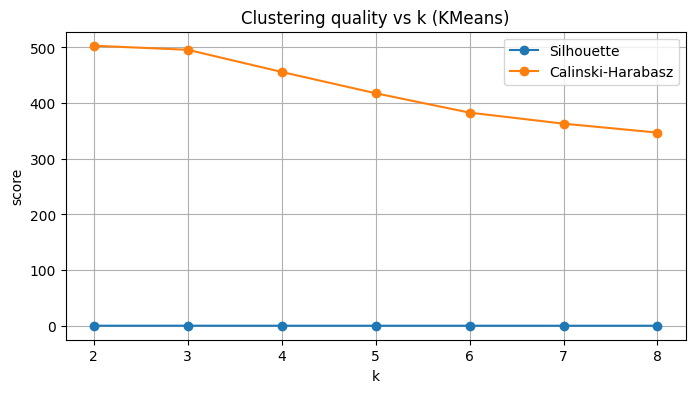

Best k (by silhouette): 3


In [3]:
# Run KMeans over a range of k and record silhouette & calinski scores
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, calinski_harabasz_score

ks = list(range(2,9))
sil_scores = []
ch_scores = []
for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    sil = silhouette_score(X, labels) if len(set(labels))>1 else np.nan
    ch = calinski_harabasz_score(X, labels) if len(set(labels))>1 else np.nan
    sil_scores.append(sil)
    ch_scores.append(ch)

import matplotlib.pyplot as plt
plt.figure(figsize=(8,4))
plt.plot(ks, sil_scores, marker='o', label='Silhouette')
plt.plot(ks, ch_scores, marker='o', label='Calinski-Harabasz')
plt.xlabel('k')
plt.ylabel('score')
plt.legend()
plt.title('Clustering quality vs k (KMeans)')
plt.grid(True)
plt.savefig(OUT / 'k_vs_scores.png', bbox_inches='tight')
plt.show()

# pick best k by max silhouette (ignore nan)
best_idx = int(np.nanargmax(sil_scores))
best_k = ks[best_idx]
print('Best k (by silhouette):', best_k)


In [4]:
# Fit final KMeans and save labels + model
best_k = int(best_k)
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
k_labels = kmeans.fit_predict(X)
df_out = df.copy()
df_out['kmeans_label'] = k_labels
df_out.to_csv(PROC / 'clients_clusters_kmeans.csv')
joblib.dump(kmeans, MODELS / f'kmeans_k{best_k}.joblib')
print('Saved KMeans labels and model')


Saved KMeans labels and model


In [5]:
# Agglomerative clustering (same k)
agg = AgglomerativeClustering(n_clusters=best_k)
a_labels = agg.fit_predict(X)
from sklearn.metrics import adjusted_rand_score
print('ARI between KMeans and Agglomerative:', adjusted_rand_score(k_labels, a_labels))
df_out['agg_label'] = a_labels
df_out.to_csv(PROC / 'clients_clusters_agg.csv')
print('Saved Agglomerative labels')

ARI between KMeans and Agglomerative: 0.5923361010648814
Saved Agglomerative labels


In [6]:
# DBSCAN quick try (may produce noise cluster -1)
db = DBSCAN(eps=0.5, min_samples=5)
db_labels = db.fit_predict(X)
unique = set(db_labels)
print('DBSCAN produced', len(unique), 'labels (including noise)')
df_out['dbscan_label'] = db_labels
df_out.to_csv(PROC / 'clients_clusters_dbscan.csv')
print('Saved DBSCAN labels')

DBSCAN produced 22 labels (including noise)
Saved DBSCAN labels


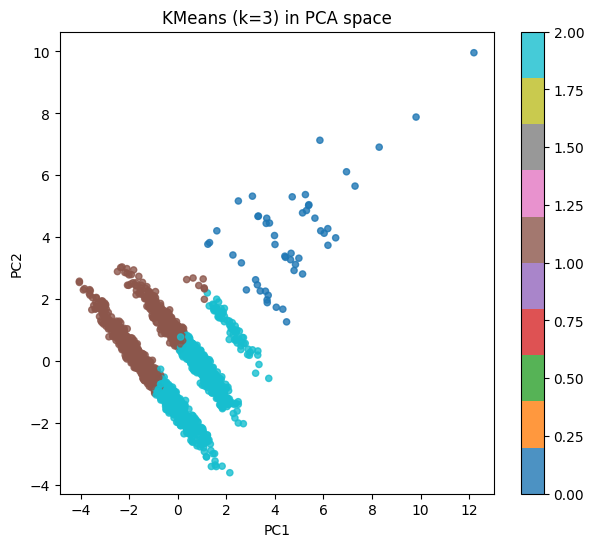

Saved combined cluster labels to /Users/gokulmallabathula/Buyer Segementation and Investment Profiling/parcl-buyer-segmentation/data/processed/clients_clusters_all.csv


In [7]:
# 2D visualization with PCA
pca = PCA(n_components=2)
Z = pca.fit_transform(X)
plt.figure(figsize=(7,6))
plt.scatter(Z[:,0], Z[:,1], c=k_labels, cmap='tab10', s=20, alpha=0.8)
plt.title(f'KMeans (k={best_k}) in PCA space')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.colorbar()
plt.savefig(OUT / 'kmeans_pca_scatter.png', bbox_inches='tight')
plt.show()

# save final CSV with all labels
df_out.to_csv(PROC / 'clients_clusters_all.csv')
print('Saved combined cluster labels to', (PROC / 'clients_clusters_all.csv'))